In [1]:
from io import StringIO
import matplotlib.pyplot as plt
import pandas as pd
import os,glob
os.chdir('F:\\geodata\\river_runoff_obs\\concern_snow_melt')

In [2]:
# Raw data as a string
data = """
abbre,ssp126,ssp245,ssp370,ssp585
hsg, 	2020,	2019,	2021,	2021
dsk,	2026,	2027,	2029,	2032
xhl,	2042,	2053,	2055,	2049
slglk,	2042,	2054,	2056,	2058
kq,		2055,	2077,	2074,	2078
wlwt,	2064,	2077,	2093,	2084
tgzlk,	2069,	2080,	2094,	2094
"""

# Use StringIO to simulate a file
data_io = StringIO(data)

# Read the data into a DataFrame
peak_water_df = pd.read_csv(data_io,index_col=0)

# Display the DataFrame
print(peak_water_df)

       ssp126  ssp245  ssp370  ssp585
abbre                                
hsg      2020    2019    2021    2021
dsk      2026    2027    2029    2032
xhl      2042    2053    2055    2049
slglk    2042    2054    2056    2058
kq       2055    2077    2074    2078
wlwt     2064    2077    2093    2084
tgzlk    2069    2080    2094    2094


In [3]:
colors = ['#00008B', '#FFA500', '#FF0000', '#B22222']  # Define colors for the 4 scenarios

In [4]:
file_name_list = ['1_hsg_imputMF','2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']

In [5]:
import pymannkendall as mk

hsg ssp126
hsg ssp245
hsg ssp370
hsg ssp585
dsk ssp126
dsk ssp245
dsk ssp370
dsk ssp585
xhl ssp126
xhl ssp245
xhl ssp370
xhl ssp585
slglk ssp126
slglk ssp245
slglk ssp370
slglk ssp585
kq ssp126
kq ssp245
kq ssp370
kq ssp585
wlwt ssp126
wlwt ssp245
wlwt ssp370
wlwt ssp585
tgzlk ssp126
tgzlk ssp245
tgzlk ssp370
tgzlk ssp585


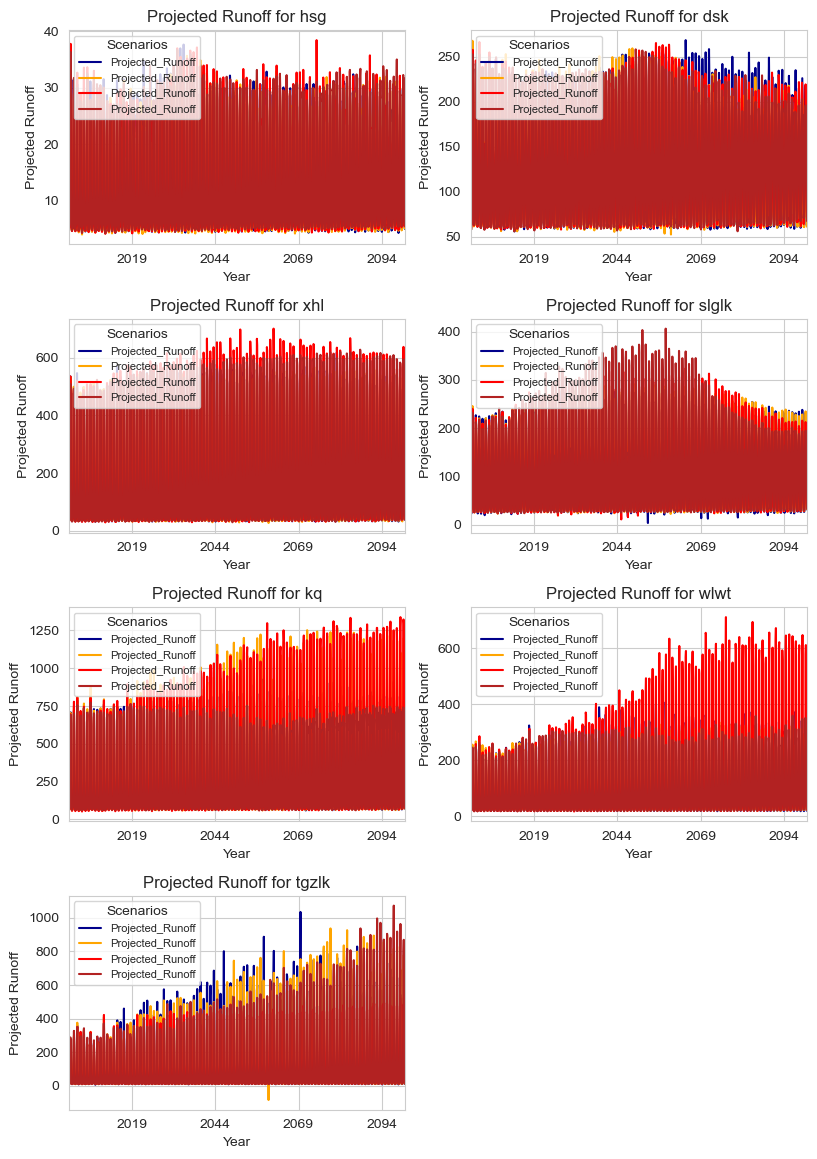

In [6]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)
        annual_mean_df = mean_df.resample('YE').mean()
        annual_mean_df.index = annual_mean_df.index.year
        annual_std_dev.index = annual_std_dev.index.year

        # Plot the mean 'Projected_Runoff' for the current scenario with color

        mean_df['Projected_Runoff'].plot(ax=ax, color=colors[j])
        # ax.plot(
        #     # mean_df.index,
        #     mean_df['Projected_Runoff'],
        #     label=scenario,
        #     color=colors[j]  # Set the color based on the scenario index
        # )
        # ax.fill_between(
        #     annual_std_dev.index,
        #     -annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
        #     annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
        #     color=colors[j],  # Set the color based on the scenario index
        #     alpha=0.3,
        # )

    # Customize the subplot
    ax.set_title(f'Projected Runoff for {abbre}')
    # ax.set_xlim(2000, 2100)
    ax.set_xlabel('Year')
    ax.set_ylabel('Projected Runoff')
    ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

hsg ssp126 0.05172881053835843 0.05172881053835843
hsg ssp245 0.08750648619082013 0.08750648619082013
hsg ssp370 0.0819073415609306 0.0819073415609306
hsg ssp585 0.3322110181809792 0.3322110181809792
dsk ssp126 0.01492200192849169 0.01492200192849169
dsk ssp245 -0.005048530615233138 -0.005048530615233138
dsk ssp370 0.0855332354988656 0.0855332354988656
dsk ssp585 0.10422644895374189 0.10422644895374189
xhl ssp126 0.10733735752733775 0.10733735752733775
xhl ssp245 0.23138759751195326 0.23138759751195326
xhl ssp370 0.3531550556750067 0.3531550556750067
xhl ssp585 0.4918578013393444 0.4918578013393444
slglk ssp126 0.08063038071984141 0.08063038071984141
slglk ssp245 0.08692297592199472 0.08692297592199472
slglk ssp370 0.13212486018215563 0.13212486018215563
slglk ssp585 0.16835583024328282 0.16835583024328282
kq ssp126 0.1110461042778561 0.1110461042778561
kq ssp245 0.547342106671985 0.547342106671985
kq ssp370 0.9269628327593791 0.9269628327593791
kq ssp585 0.47706631109215913 0.47706631

C:\Users\HP\AppData\Local\Temp\ipykernel_138032\3854419192.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


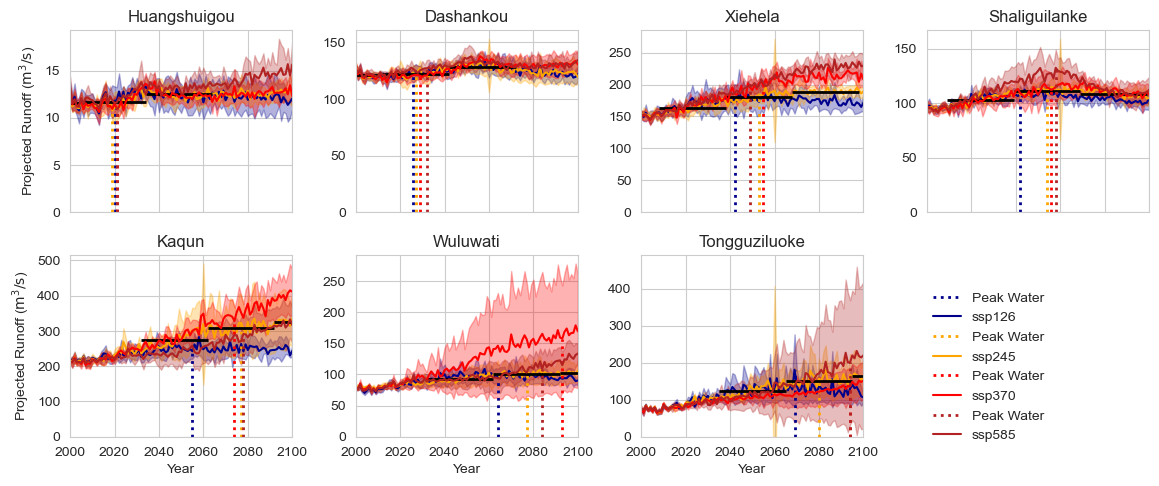

In [7]:
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)
        annual_mean_df = mean_df.resample('YE').mean()
        annual_mean_df.index = annual_mean_df.index.year
        annual_std_dev.index = annual_std_dev.index.year

        peak_water_timing = float(peak_water_df.loc[abbre,scenario])
        peak_water = annual_mean_df['Projected_Runoff'][int(peak_water_timing)]
        ax.vlines(x=float(peak_water_df.loc[abbre,scenario]), ymin = 0  * peak_water, ymax = peak_water, colors=colors[j], linestyles='dotted', linewidth=2, label='Peak Water')
        # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            annual_mean_df.index,
            annual_mean_df['Projected_Runoff'],
            label=scenario,
            color=colors[j]  # Set the color based on the scenario index
        )
        ax.fill_between(
            annual_std_dev.index,
            -annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
            annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
            color=colors[j],  # Set the color based on the scenario index
            alpha=0.3,
        )

        # Get the peak water year for the current station and scenario
        peak_year = peak_water_df.loc[abbre, scenario]
        # Split data into before and after peak water year
        before_peak = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= peak_year - 45) & (annual_mean_df.index < peak_year-15)
        ]
        after_peak  = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= peak_year + 15) & (annual_mean_df.index  < peak_year+45)
        ]
        during_peak = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= peak_year - 15) & (annual_mean_df.index  < peak_year+15)
        ]
        during_2000_2015 = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= 2000) & (annual_mean_df.index  < 2015)
        ]
        during_end = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= 2100)
        ]


        if scenario == 'ssp245':
            ax.hlines(y= before_peak.mean(),xmax = peak_year-15 , xmin= peak_year-45, color='black', linewidth=2)
            ax.hlines(y= during_peak.mean(),xmax = peak_year+15 , xmin= peak_year-15, color='black', linewidth=2)
            ax.hlines(y= after_peak.mean(),xmax = peak_year+45 , xmin= peak_year+15, color='black', linewidth=2)


        # mk_result_before = mk.original_test(before_peak)
        # mk_result_after  = mk.original_test( after_peak)
        # print(abbre, scenario, mk_result_before.slope, mk_result_before.p, mk_result_after.slope,mk_result_after.p , '\n')
        # print(abbre, scenario, during_peak.mean()/ before_peak.mean()-1,after_peak.mean()/before_peak.mean()-1)
        print(abbre, scenario, during_end.mean()/ during_2000_2015.mean()-1,during_end.mean()/during_2000_2015.mean()-1)

        # mk_result  = mk.original_test(annual_mean_df['Projected_Runoff'])
        # print(abbre, scenario,mk_result.trend)

    # ax.plot(
    #     annual_mean_df.index,
    #     annual_mean_df['dis'],
    #     label='observation',
    #     color='black'  # Set the color based on the scenario index
    # )
    # Customize the subplot
    ax.set_title(station_names[i])
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom = 0.4 * peak_water)
    ax.set_ylim(bottom = 0)
    ax.set_xlabel('Year')
    ax.set_ylabel(r'Projected Runoff ($\mathrm{m^3/s}$)')
    # ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)
    ax.set_facecolor('white')  # or 'none'

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

# Adjust layout
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figure2_river_runoffsnow.svg', facecolor='white')
plt.show()

In [8]:
month_mapping = {1: 4, 2: 5, 3: 6, 4: 7, 5: 8, 6: 9, 7: 10, 8: 11, 9: 12, 10: 1, 11: 2, 12: 3}

hsg ssp245
Huangshuigou ssp245 6.950575926950961 6.90402191810473 6.879503418634354
hsg ssp585
Huangshuigou ssp585 6.921488659078044 6.892248594033247 6.876684148854045
dsk ssp245
Dashankou ssp245 6.747201533513322 6.737359827922925 6.735708675481855
dsk ssp585
Dashankou ssp585 6.759559566101822 6.728166931300919 6.702256139292229
xhl ssp245


<>:119: SyntaxWarning: invalid escape sequence '\m'
<>:119: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_138032\535971127.py:119: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


Xiehela ssp245 7.140229046168675 7.100568164916119 7.075784148166341
xhl ssp585
Xiehela ssp585 7.140899108220746 7.114507419931858 7.088639766744994
slglk ssp245
Shaliguilanke ssp245 6.8383685927178295 6.869972091867379 6.818463056665869
slglk ssp585
Shaliguilanke ssp585 6.849351557653677 6.880233671671826 6.772278767659991
kq ssp245
Kaqun ssp245 7.216350931661091 7.255633865821988 7.234793357856842
kq ssp585
Kaqun ssp585 7.151156429417587 7.10862761083244 7.0481177932441845
wlwt ssp245
Wuluwati ssp245 7.033476548555062 7.056365014797364 7.04303379287497
wlwt ssp585
Wuluwati ssp585 7.025459235540354 7.0338694310414756 7.063472938223575
tgzlk ssp245
Tongguziluoke ssp245 7.323246444030955 7.388200789603715 7.365904957490086
tgzlk ssp585
Tongguziluoke ssp585 7.326907149181586 7.4428798135523655 nan


C:\Users\HP\AppData\Local\Temp\ipykernel_138032\535971127.py:105: RuntimeWarning: invalid value encountered in scalar divide
  after_center_of_mass = (after_mean_df.index.astype('int64') * after_mean_df['Projected_Runoff']).sum() / after_mean_df['Projected_Runoff'].sum()
C:\Users\HP\AppData\Local\Temp\ipykernel_138032\535971127.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


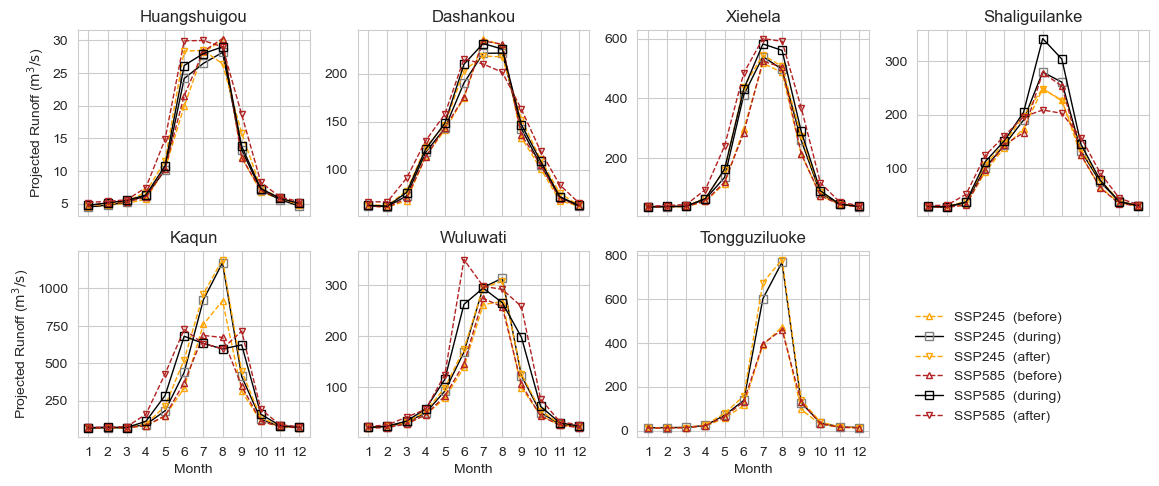

In [9]:
annual_mean_df['Projected_Runoff'][2005]
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp245', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # if peak_water_df.loc[abbre,scenario] > 2055:
        #     continue

        # Split data into 3 periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario]) -15]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario]) +15]
        during_peak_water_df = mean_df[(mean_df.index.year > float(peak_water_df.loc[abbre, scenario]) - 15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 15)]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy
        during_peak_water_df = during_peak_water_df.copy() # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month
        during_peak_water_df.loc[:,'month'] = during_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()
        during_mean_df = during_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['Projected_Runoff'],
            label=f"{scenario.upper()}  (before)",
            color=colors[2*j +1],  # Set the color based on the scenario index
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )

        if peak_water_df.loc[abbre,scenario]<2094:
            ax.plot(
                during_mean_df.index,
                during_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (during)",
                color='black',  # Set the color based on the scenario index
                marker="s",        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                markeredgecolor= 'grey' if scenario!='ssp585' else 'black',  # Set the color based on the scenario index
                linestyle='-',
                linewidth=1,
                markersize=6
            )
            ax.plot(
                after_mean_df.index,
                after_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (after)",
                color=colors[2*j +1],  # Set the color based on the scenario index
                marker='v',        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='--',
                linewidth=1,
                markersize=5
            )

        # print(((during_mean_df['Projected_Runoff'][5:8] / before_mean_df['Projected_Runoff'])[5:8]).mean() -1)
        before_mean_df['Projected_Runoff'].index = before_mean_df['Projected_Runoff'].replace(month_mapping)
        during_mean_df['Projected_Runoff'].index = during_mean_df['Projected_Runoff'].replace(month_mapping)
        after_mean_df['Projected_Runoff'].index = after_mean_df['Projected_Runoff'].replace(month_mapping)

        before_center_of_mass = (before_mean_df.index.astype('int64') * before_mean_df['Projected_Runoff']).sum() / before_mean_df['Projected_Runoff'].sum()
        during_center_of_mass = (during_mean_df.index.astype('int64') * during_mean_df['Projected_Runoff']).sum() / during_mean_df['Projected_Runoff'].sum()
        after_center_of_mass = (after_mean_df.index.astype('int64') * after_mean_df['Projected_Runoff']).sum() / after_mean_df['Projected_Runoff'].sum()
        print(station_names[i],scenario,before_center_of_mass,during_center_of_mass,after_center_of_mass)


        # print(station_names[i],scenario,'before',((before_mean_df['Projected_Runoff'][5:8].sum() / before_mean_df['Projected_Runoff'].sum())) )
        # print(station_names[i],scenario,'during',((during_mean_df['Projected_Runoff'][5:8].sum() / during_mean_df['Projected_Runoff'].sum())) )
        # print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:
            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.set_xlabel('Month')

    ax.set_title(station_names[i])  # Assign the corresponding title

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Month')
    # ax.set_ylim(bottom = 0,top = 100)
    ax.set_facecolor('white')  # or 'none'


# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure2_1_SSP245_SSP585snow.svg')
plt.show()

<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_138032\288650215.py:105: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


hsg ssp126
Huangshuigou ssp126 before 0.5679687871045919
Huangshuigou ssp126 during 0.5644757494788768
Huangshuigou ssp126 after 0.5555222112961022
hsg ssp245
Huangshuigou ssp245 before 0.5667500287705618
Huangshuigou ssp245 during 0.5613676721799126
Huangshuigou ssp245 after 0.5532290886957485
hsg ssp370
Huangshuigou ssp370 before 0.5721066211073541
Huangshuigou ssp370 during 0.562318227275194
Huangshuigou ssp370 after 0.5318213834749771
hsg ssp585
Huangshuigou ssp585 before 0.5660460034147827
Huangshuigou ssp585 during 0.5629369103921227
Huangshuigou ssp585 after 0.5366280547843505
dsk ssp126
Dashankou ssp126 before 0.44290604084794716
Dashankou ssp126 during 0.43573681969143185
Dashankou ssp126 after 0.4428146636124989
dsk ssp245
Dashankou ssp245 before 0.44178162068344473
Dashankou ssp245 during 0.43050081114338745
Dashankou ssp245 after 0.42232839646108483
dsk ssp370
Dashankou ssp370 before 0.44068059446987173
Dashankou ssp370 during 0.42646985551116484
Dashankou ssp370 after 0.42

C:\Users\HP\AppData\Local\Temp\ipykernel_138032\288650215.py:96: RuntimeWarning: invalid value encountered in scalar divide
  print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )
C:\Users\HP\AppData\Local\Temp\ipykernel_138032\288650215.py:96: RuntimeWarning: invalid value encountered in scalar divide
  print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )
C:\Users\HP\AppData\Local\Temp\ipykernel_138032\288650215.py:96: RuntimeWarning: invalid value encountered in scalar divide
  print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )
C:\Users\HP\AppData\Local\Temp\ipykernel_138032\288650215.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called wi

Tongguziluoke ssp126 before 0.7845470574787986
Tongguziluoke ssp126 during 0.823021678697211
Tongguziluoke ssp126 after 0.8147622455280774
tgzlk ssp245
Tongguziluoke ssp245 before 0.7848858559573713
Tongguziluoke ssp245 during 0.8208854557743295
Tongguziluoke ssp245 after 0.8198916895562577
tgzlk ssp370
Tongguziluoke ssp370 before 0.7530380758651383
Tongguziluoke ssp370 during 0.7177373318156997
Tongguziluoke ssp370 after nan
tgzlk ssp585
Tongguziluoke ssp585 before 0.7591802194954828
Tongguziluoke ssp585 during 0.7603210420273604
Tongguziluoke ssp585 after nan


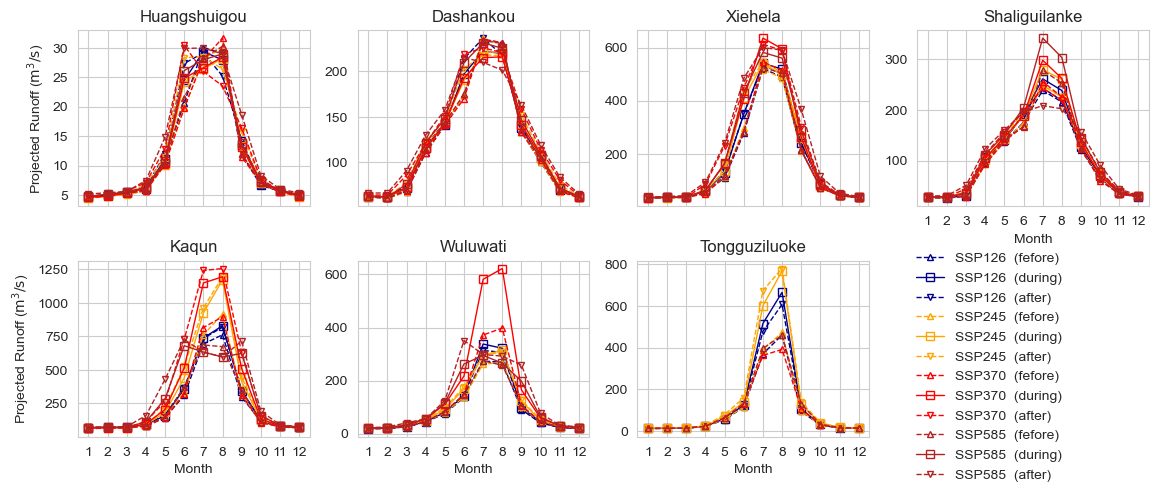

In [12]:
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into 3 periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario]) -15]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario]) +15]
        during_peak_water_df = mean_df[(mean_df.index.year > float(peak_water_df.loc[abbre, scenario]) - 15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 15)]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy
        during_peak_water_df = during_peak_water_df.copy() # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month
        during_peak_water_df.loc[:,'month'] = during_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()
        during_mean_df = during_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['Projected_Runoff'],
            label=f"{scenario.upper()}  (fefore)",
            color=colors[j],  # Set the color based on the scenario index
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )

        if peak_water_df.loc[abbre,scenario]<2094:

            ax.plot(
                during_mean_df.index,
                during_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (during)",
                color=colors[j],  # Set the color based on the scenario index
                marker="s",        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='-',
                linewidth=1,
                markersize=6
            )
            ax.plot(
                after_mean_df.index,
                after_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (after)",
                color=colors[j],  # Set the color based on the scenario index
                marker='v',        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='--',
                linewidth=1,
                markersize=5
            )
        # print(((during_mean_df['Projected_Runoff'][4:9] / before_mean_df['Projected_Runoff'])[4:9]).mean() -1)
        print(station_names[i],scenario,'before',((before_mean_df['Projected_Runoff'][5:8].sum() / before_mean_df['Projected_Runoff'].sum())) )
        print(station_names[i],scenario,'during',((during_mean_df['Projected_Runoff'][5:8].sum() / during_mean_df['Projected_Runoff'].sum())) )
        print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.set_xlabel('Month')

    ax.set_title(station_names[i])  # Assign the corresponding title

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 5:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure2_1snowsnow.svg')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_138032\3529195280.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


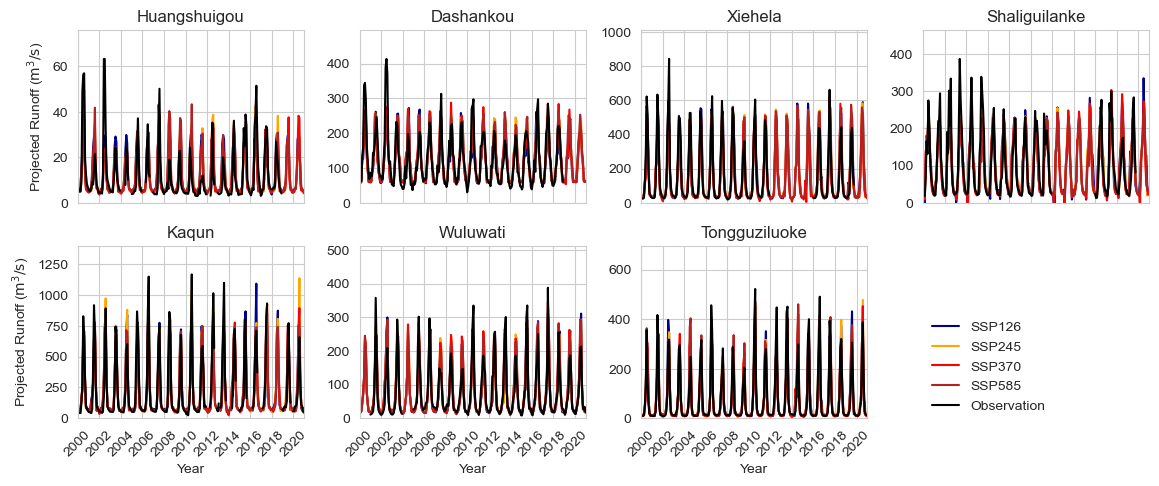

In [13]:
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis



    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        total_mon_df = sum(mon_df_list) / len(station_names)

        ax.plot(
                mon_df.index,
            mon_df['Projected_Runoff'],
            label=['SSP126', 'SSP245', 'SSP370', 'SSP585'][j],
            color=colors[j],  # Set the color based on the scenario index
        )
    ax.plot(
        mon_df.index,
        mon_df['dis'],
        label='Observation',
        color='black'  # Set the color based on the scenario index
    )
    # # Customize the subplot
    ax.set_title(station_names[i])
    ax.set_xlim(pd.to_datetime("2000-01-01"), pd.to_datetime("2020-12-31"))
    ax.set_ylim(bottom =0, top = mon_df['dis'].max()*1.2)
    # ax.set_ylim(bottom = 0)
    ax.tick_params(axis='x', rotation=45)   # rotate by 45 degrees
    ax.set_xlabel('Year')
    ax.set_ylabel(r'Projected Runoff ($\mathrm{m^3/s}$)')
    # ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)
    ax.set_facecolor('white')  # or 'none'



# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

# Adjust layout
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figure_snow_melt_river_runoff.svg', facecolor='white')
plt.show()

In [15]:
2360-1084/2

1818.0